# Step 8 — Constitution + Culture Model

**Design:**
- Same CatBoost setup as Step 3 (depth=2, 1000 iters, country-blocked 5-fold CV)
- Adds one feature: EIU Democratic Culture Index (`dem_culture`, 0–10)
- Dataset restricted to years with EIU coverage (2006, 2008, 2010–2024)
- Two models run on the **same rows** for a fair comparison:
  - **Model A:** 14 constitutional dimensions only
  - **Model B:** 14 constitutional dimensions + dem_culture

**Key question:** How much does culture add once you control for the data restriction?
The Step 3 R²=0.17 used all years; this recomputes on the EIU-window subset.

**Inputs:** `ccpc_axis_scores_llm.csv` · `vdem/vdem_data.csv` · EIU culture CSV  
**Outputs:** `backsliding_gap_culture.csv` · `feature_importances_culture.csv`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.model_selection import GroupKFold
from sklearn.metrics import r2_score, mean_squared_error
from catboost import CatBoostRegressor
import warnings
warnings.filterwarnings('ignore')
print('Libraries loaded.')

Libraries loaded.


In [2]:
SCORES_PATH = 'ccpc_axis_scores_llm.csv'
VDEM_PATH   = 'data/vdem/vdem_data.csv'
EIU_PATH    = 'data/eiu/democratic-culture-index-eiu.csv'
TARGET      = 'v2x_polyarchy'
K           = 5
RANDOM_STATE = 42
TEST_YEARS  = list(range(2016, 2024))

CONST_FEATURES = [
    'ccpc_civil_liberties',
    'ccpc_socioeconomic_rights',
    'ccpc_political_competition',
    'ccpc_legislative_autonomy',
    'ccpc_executive_constraints',
    'ccpc_judicial_independence',
    'ccpc_rule_of_law_due_process',
    'ccpc_institutional_accountability',
    'ccpc_emergency_powers_constraints',
    'ccpc_civilian_control_of_security',
    'ccpc_amendment_rigidity',
    'ccpc_federalism_decentralization',
    'ccpc_transparency_information_access',
    'ccpc_equality_gender_minority_indigenous',
]
CULTURE_FEATURES = CONST_FEATURES + ['dem_culture']

LABELS = {
    'ccpc_civil_liberties':                     'Civil liberties',
    'ccpc_socioeconomic_rights':                'Socioeconomic rights',
    'ccpc_political_competition':               'Political competition',
    'ccpc_legislative_autonomy':                'Legislative autonomy',
    'ccpc_executive_constraints':               'Executive constraints',
    'ccpc_judicial_independence':               'Judicial independence',
    'ccpc_rule_of_law_due_process':             'Rule of law / due process',
    'ccpc_institutional_accountability':        'Institutional accountability',
    'ccpc_emergency_powers_constraints':        'Emergency powers constraints',
    'ccpc_civilian_control_of_security':        'Civilian control of security',
    'ccpc_amendment_rigidity':                  'Amendment rigidity',
    'ccpc_federalism_decentralization':         'Federalism / decentralization',
    'ccpc_transparency_information_access':     'Transparency / info access',
    'ccpc_equality_gender_minority_indigenous': 'Equality (gender/minority/indigenous)',
    'dem_culture':                              'Democratic culture (EIU)',
}

print(f'Constitutional features : {len(CONST_FEATURES)}')
print(f'Culture model features  : {len(CULTURE_FEATURES)}')
print(f'K                       : {K} country-blocked folds')

Constitutional features : 14
Culture model features  : 15
K                       : 5 country-blocked folds


## 1 — Load & Merge

In [3]:
ccpc = pd.read_csv(SCORES_PATH)
ccpc['cowcode'] = pd.to_numeric(ccpc['cowcode'], errors='coerce').astype('Int64')
ccpc['year']    = pd.to_numeric(ccpc['year'],    errors='coerce').astype('Int64')

vdem = pd.read_csv(VDEM_PATH, usecols=['country_name', 'country_text_id', 'COWcode', 'year', TARGET])
vdem['COWcode'] = pd.to_numeric(vdem['COWcode'], errors='coerce').astype('Int64')

eiu = pd.read_csv(EIU_PATH).rename(columns={
    'Entity': 'country', 'Code': 'iso3', 'Year': 'year',
    'Democratic Culture Index': 'dem_culture'
})[['iso3', 'year', 'dem_culture']].dropna()

# Merge V-Dem + CCPC (all years)
df_full = vdem.merge(
    ccpc[['cowcode', 'year'] + CONST_FEATURES],
    left_on=['COWcode', 'year'], right_on=['cowcode', 'year'], how='inner'
).drop(columns=['cowcode'])

# Merge EIU — restricts to EIU-covered years
df = df_full.merge(eiu, left_on=['country_text_id', 'year'], right_on=['iso3', 'year'], how='inner')
df = df.drop(columns=['iso3'])
df = df.dropna(subset=[TARGET])
df = df.dropna(subset=CONST_FEATURES, how='all')
df = df.reset_index(drop=True)

print(f'Full dataset (all years):   {len(df_full):,} rows | {df_full["COWcode"].nunique()} countries')
print(f'EIU-window dataset:         {len(df):,} rows | {df["COWcode"].nunique()} countries | years: {df["year"].min()}–{df["year"].max()}')
print(f'\nCulture score coverage:     {df["dem_culture"].notna().sum():,} / {len(df):,} rows ({df["dem_culture"].notna().mean()*100:.1f}%)')
df[['v2x_polyarchy', 'dem_culture']].describe().round(3)

Full dataset (all years):   15,738 rows | 185 countries
EIU-window dataset:         2,493 rows | 160 countries | years: 2006–2023

Culture score coverage:     2,493 / 2,493 rows (100.0%)


,v2x_polyarchy,dem_culture
count,2493.000,2493.000
mean,0.525,5.518
std,0.257,1.698
min,0.014,1.250
25%,0.299,4.380
50%,0.526,5.630
75%,0.765,6.250
max,0.922,10.000


## 2 — Country-Blocked 5-Fold CV: Two Models on the Same Rows

Both models use identical folds (same `GroupKFold` splits) so the R² comparison is
purely about the feature set, not randomness in splitting.

In [4]:
def run_cv(df, features, label):
    gkf    = GroupKFold(n_splits=K)
    groups = df['COWcode'].values
    oof    = np.full(len(df), np.nan)
    fold_r2s, fold_rmses = [], []

    for fold, (tr, te) in enumerate(gkf.split(df, groups=groups)):
        m = CatBoostRegressor(
            iterations=1000, learning_rate=0.05, depth=2,
            l2_leaf_reg=5, loss_function='RMSE',
            random_seed=RANDOM_STATE, verbose=0, early_stopping_rounds=30,
        )
        X_tr = df.iloc[tr][features].copy()
        X_te = df.iloc[te][features].copy()
        y_tr = df.iloc[tr][TARGET].values
        y_te = df.iloc[te][TARGET].values

        # Fill missing culture with fold-train median (only relevant for Model A rows)
        for col in features:
            med = X_tr[col].median()
            X_tr[col] = X_tr[col].fillna(med)
            X_te[col] = X_te[col].fillna(med)

        m.fit(X_tr.values, y_tr, eval_set=(X_te.values, y_te))
        preds = m.predict(X_te.values)
        oof[te] = preds

        r2   = r2_score(y_te, preds)
        rmse = mean_squared_error(y_te, preds) ** 0.5
        fold_r2s.append(r2)
        fold_rmses.append(rmse)

    oof_r2   = r2_score(df[TARGET].values, oof)
    cv_r2    = np.mean(fold_r2s)
    cv_std   = np.std(fold_r2s)
    cv_rmse  = np.mean(fold_rmses)

    print(f'\n{label}')
    print(f'  Fold R²:      {" | ".join(f"{r:.4f}" for r in fold_r2s)}')
    print(f'  Avg fold R²:  {cv_r2:.4f} ± {cv_std:.4f}')
    print(f'  Overall OOF R²: {oof_r2:.4f}')
    print(f'  Avg RMSE:     {cv_rmse:.4f}')
    return oof, oof_r2, cv_r2, cv_std, cv_rmse

# Model A: constitution only (recomputed on the EIU-window rows for fair comparison)
oof_A, oof_r2_A, cv_r2_A, cv_std_A, cv_rmse_A = run_cv(df, CONST_FEATURES,    'Model A — Constitution only (14 features, EIU-window rows)')

# Model B: constitution + culture
oof_B, oof_r2_B, cv_r2_B, cv_std_B, cv_rmse_B = run_cv(df, CULTURE_FEATURES,  'Model B — Constitution + Culture (15 features)')

print(f'\n{"="*55}')
print(f'  R² lift from adding culture:  +{oof_r2_B - oof_r2_A:.4f} (OOF)')
print(f'  Fold-avg lift:                +{cv_r2_B  - cv_r2_A:.4f}')
print(f'  Step 3 baseline (all years):   0.1734')
print(f'  Model A (same rows):           {oof_r2_A:.4f}')
print(f'  Model B (+ culture):           {oof_r2_B:.4f}')


Model A — Constitution only (14 features, EIU-window rows)
  Fold R²:      0.0813 | 0.1226 | -0.0036 | -0.0274 | 0.0775
  Avg fold R²:  0.0501 ± 0.0564
  Overall OOF R²: 0.0668
  Avg RMSE:     0.2474



Model B — Constitution + Culture (15 features)
  Fold R²:      0.4604 | 0.6340 | 0.3421 | 0.3100 | 0.2195
  Avg fold R²:  0.3932 ± 0.1430
  Overall OOF R²: 0.4015
  Avg RMSE:     0.1965

  R² lift from adding culture:  +0.3347 (OOF)
  Fold-avg lift:                +0.3431
  Step 3 baseline (all years):   0.1734
  Model A (same rows):           0.0668
  Model B (+ culture):           0.4015


## 3 — Final Models for Feature Importances

In [5]:
def train_final(df, features):
    X = df[features].copy()
    for col in features:
        X[col] = X[col].fillna(X[col].median())
    m = CatBoostRegressor(
        iterations=1000, learning_rate=0.05, depth=2,
        l2_leaf_reg=5, loss_function='RMSE',
        random_seed=RANDOM_STATE, verbose=0,
    )
    m.fit(X.values, df[TARGET].values)
    return m

model_A = train_final(df, CONST_FEATURES)
model_B = train_final(df, CULTURE_FEATURES)
print('Final models trained.')

Final models trained.


## 4 — Feature Importances: Where Does Culture Rank?

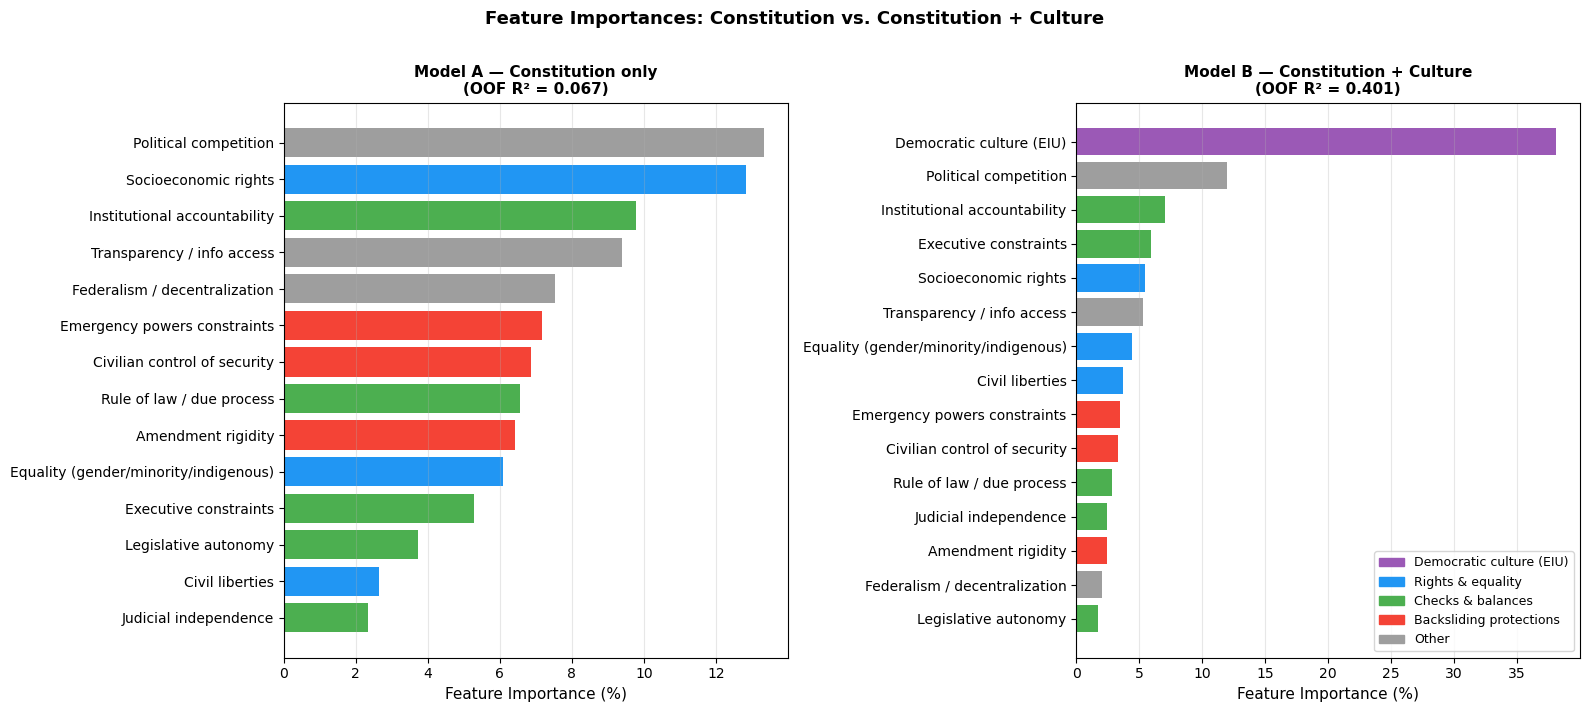

Saved: step8_feature_importances.png

Model B importances:
                                label  importance
             Democratic culture (EIU)   38.078100
                Political competition   11.982887
         Institutional accountability    7.015427
                Executive constraints    5.949048
                 Socioeconomic rights    5.416475
           Transparency / info access    5.272694
Equality (gender/minority/indigenous)    4.414102
                      Civil liberties    3.736814
         Emergency powers constraints    3.493105
         Civilian control of security    3.273852
            Rule of law / due process    2.797536
                Judicial independence    2.429474
                   Amendment rigidity    2.396552
        Federalism / decentralization    2.057856
                 Legislative autonomy    1.686077


In [6]:
RIGHTS  = {'ccpc_civil_liberties', 'ccpc_socioeconomic_rights', 'ccpc_equality_gender_minority_indigenous'}
CHECKS  = {'ccpc_executive_constraints', 'ccpc_judicial_independence', 'ccpc_legislative_autonomy',
           'ccpc_institutional_accountability', 'ccpc_rule_of_law_due_process'}
PROTECT = {'ccpc_emergency_powers_constraints', 'ccpc_amendment_rigidity', 'ccpc_civilian_control_of_security'}

def bar_color(f):
    if f == 'dem_culture': return '#9B59B6'
    if f in RIGHTS:        return '#2196F3'
    if f in CHECKS:        return '#4CAF50'
    if f in PROTECT:       return '#F44336'
    return '#9E9E9E'

imp_B = (pd.DataFrame({'feature': CULTURE_FEATURES,
                        'importance': model_B.get_feature_importance()})
          .sort_values('importance', ascending=False).reset_index(drop=True))
imp_B['label'] = imp_B['feature'].map(LABELS)

imp_A = (pd.DataFrame({'feature': CONST_FEATURES,
                        'importance': model_A.get_feature_importance()})
          .sort_values('importance', ascending=False).reset_index(drop=True))
imp_A['label'] = imp_A['feature'].map(LABELS)

fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharey=False)

for ax, imp, title in [
    (axes[0], imp_A, f'Model A — Constitution only\n(OOF R² = {oof_r2_A:.3f})'),
    (axes[1], imp_B, f'Model B — Constitution + Culture\n(OOF R² = {oof_r2_B:.3f})'),
]:
    colors = [bar_color(f) for f in imp['feature']]
    ax.barh(imp['label'], imp['importance'], color=colors)
    ax.invert_yaxis()
    ax.set_xlabel('Feature Importance (%)', fontsize=11)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.grid(axis='x', alpha=0.3)

legend_handles = [
    mpatches.Patch(color='#9B59B6', label='Democratic culture (EIU)'),
    mpatches.Patch(color='#2196F3', label='Rights & equality'),
    mpatches.Patch(color='#4CAF50', label='Checks & balances'),
    mpatches.Patch(color='#F44336', label='Backsliding protections'),
    mpatches.Patch(color='#9E9E9E', label='Other'),
]
axes[1].legend(handles=legend_handles, loc='lower right', fontsize=9)
plt.suptitle('Feature Importances: Constitution vs. Constitution + Culture', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('outputs/08_culture_constitution_model/feature_importances.png', dpi=180, bbox_inches='tight')
plt.show()
print('Saved: step8_feature_importances.png')
print()
print('Model B importances:')
print(imp_B[['label','importance']].to_string(index=False))

## 5 — R² Comparison Bar Chart

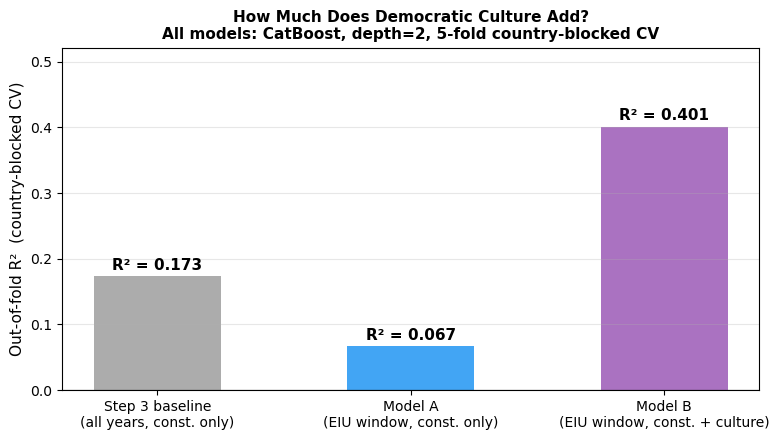

Saved: step8_r2_comparison.png


In [7]:
fig, ax = plt.subplots(figsize=(8, 4.5))

models   = ['Step 3 baseline\n(all years, const. only)', 'Model A\n(EIU window, const. only)', 'Model B\n(EIU window, const. + culture)']
r2_vals  = [0.1734, oof_r2_A, oof_r2_B]
colors   = ['#9E9E9E', '#2196F3', '#9B59B6']

bars = ax.bar(models, r2_vals, color=colors, alpha=0.85, width=0.5)
for bar, val in zip(bars, r2_vals):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.005,
            f'R² = {val:.3f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_ylabel('Out-of-fold R²  (country-blocked CV)', fontsize=11)
ax.set_title('How Much Does Democratic Culture Add?\nAll models: CatBoost, depth=2, 5-fold country-blocked CV', fontsize=11, fontweight='bold')
ax.set_ylim(0, min(1.0, max(r2_vals) + 0.12))
ax.axhline(0, color='black', lw=0.8)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('outputs/08_culture_constitution_model/r2_comparison.png', dpi=180, bbox_inches='tight')
plt.show()
print('Saved: step8_r2_comparison.png')

## 6 — Backsliding Gap with Culture Model (2016–2023)

Uses **Model B OOF predictions** — each country's gap was computed by a model that never
saw it during training. The gap now reflects what remains unexplained *after* both
constitutional text and democratic culture are accounted for.

In [8]:
df['pred_A']     = oof_A
df['pred_B']     = oof_B
df['residual_A'] = df[TARGET] - df['pred_A']
df['residual_B'] = df[TARGET] - df['pred_B']

gap_df = (
    df[df['year'].isin(TEST_YEARS)]
    .groupby('country_name')[['v2x_polyarchy', 'pred_A', 'residual_A', 'pred_B', 'residual_B', 'dem_culture']]
    .mean()
    .round(3)
)
gap_df.columns = ['Actual', 'Pred (const.)', 'Gap (const.)', 'Pred (const.+culture)', 'Gap (const.+culture)', 'Culture']

print('WORST BACKSLIDERS — Culture Model (actual below what constitution + culture predicts)')
print('='*90)
print(gap_df.sort_values('Gap (const.+culture)').head(12).to_string())

print('\nMOST RESILIENT — Culture Model')
print('='*90)
print(gap_df.sort_values('Gap (const.+culture)').tail(10).to_string())

WORST BACKSLIDERS — Culture Model (actual below what constitution + culture predicts)
              Actual  Pred (const.)  Gap (const.)  Pred (const.+culture)  Gap (const.+culture)  Culture
country_name                                                                                           
Eritrea        0.069          0.520        -0.450                  0.661                -0.591    6.880
Uganda         0.279          0.588        -0.308                  0.789                -0.510    6.880
North Korea    0.084          0.537        -0.453                  0.470                -0.386    1.250
Qatar          0.058          0.451        -0.393                  0.415                -0.357    5.630
Vietnam        0.169          0.529        -0.360                  0.514                -0.345    5.316
Nicaragua      0.218          0.537        -0.318                  0.561                -0.342    5.082
Iran           0.170          0.537        -0.367                  0.486          

## 7 — Gap Comparison: Who Changes Rank When Culture Is Added?

Biggest rank IMPROVEMENTS when culture is added (looks better with culture accounted for):
                        Actual  Gap (const.)  Gap (const.+culture)  Culture  rank_shift
country_name                                                                           
Bosnia and Herzegovina   0.520         0.001                 0.236    3.518        66.0
Russia                   0.243        -0.307                -0.022    3.048        53.0
Lebanon                  0.432        -0.231                 0.043    4.456        52.5
Jordan                   0.256        -0.341                -0.063    3.910        49.0
Trinidad and Tobago      0.786         0.229                 0.423    5.472        38.0
Indonesia                0.584         0.059                 0.158    5.082        37.0
Kuwait                   0.314        -0.194                 0.022    4.380        37.0
Namibia                  0.656         0.143                 0.240    5.630        36.0
Bulgaria                 0.64

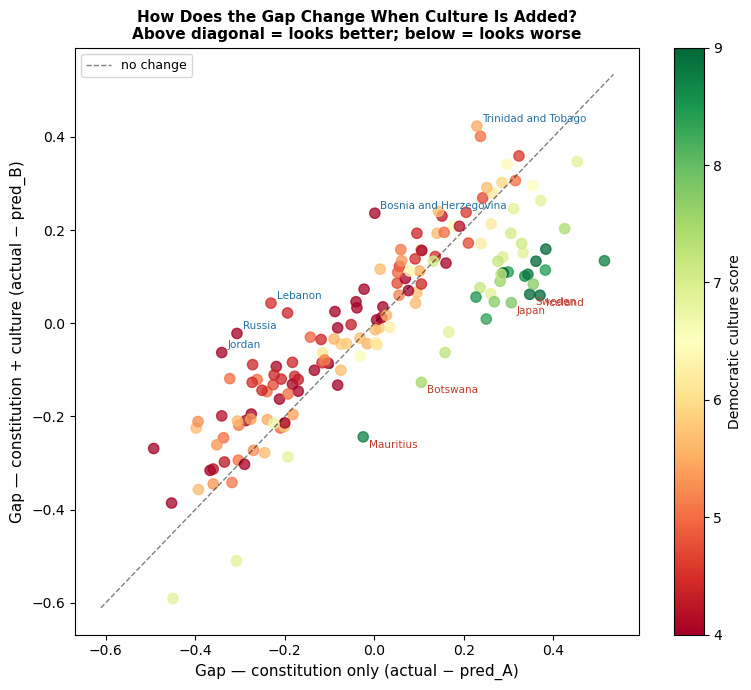

Saved: step8_gap_comparison.png


In [9]:
gap_df['rank_A'] = gap_df['Gap (const.)'].rank()
gap_df['rank_B'] = gap_df['Gap (const.+culture)'].rank()
gap_df['rank_shift'] = gap_df['rank_B'] - gap_df['rank_A']

print('Biggest rank IMPROVEMENTS when culture is added (looks better with culture accounted for):')
print(gap_df.nlargest(10, 'rank_shift')[['Actual','Gap (const.)','Gap (const.+culture)','Culture','rank_shift']].to_string())

print('\nBiggest rank DROPS when culture is added (looks worse once culture is controlled):')
print(gap_df.nsmallest(10, 'rank_shift')[['Actual','Gap (const.)','Gap (const.+culture)','Culture','rank_shift']].to_string())

# Scatter: gap A vs gap B
fig, ax = plt.subplots(figsize=(8, 7))
ax.scatter(gap_df['Gap (const.)'], gap_df['Gap (const.+culture)'],
           c=gap_df['Culture'], cmap='RdYlGn', vmin=4, vmax=9, s=55, alpha=0.75)
lo = min(gap_df['Gap (const.)'].min(), gap_df['Gap (const.+culture)'].min()) - 0.02
hi = max(gap_df['Gap (const.)'].max(), gap_df['Gap (const.+culture)'].max()) + 0.02
ax.plot([lo, hi], [lo, hi], 'k--', lw=1, alpha=0.5, label='no change')

# Label countries that shift most
for cty in gap_df.nlargest(5, 'rank_shift').index:
    r = gap_df.loc[cty]
    ax.annotate(cty, (r['Gap (const.)'], r['Gap (const.+culture)']),
                fontsize=7.5, xytext=(4, 3), textcoords='offset points', color='#2470A0')
for cty in gap_df.nsmallest(5, 'rank_shift').index:
    r = gap_df.loc[cty]
    ax.annotate(cty, (r['Gap (const.)'], r['Gap (const.+culture)']),
                fontsize=7.5, xytext=(4, -8), textcoords='offset points', color='#C0392B')

sm = plt.cm.ScalarMappable(cmap='RdYlGn', norm=plt.Normalize(vmin=4, vmax=9))
plt.colorbar(sm, ax=ax, label='Democratic culture score')
ax.set_xlabel('Gap — constitution only (actual − pred_A)', fontsize=11)
ax.set_ylabel('Gap — constitution + culture (actual − pred_B)', fontsize=11)
ax.set_title('How Does the Gap Change When Culture Is Added?\nAbove diagonal = looks better; below = looks worse', fontsize=11, fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('outputs/08_culture_constitution_model/gap_comparison.png', dpi=180, bbox_inches='tight')
plt.show()
print('Saved: step8_gap_comparison.png')

## 8 — Export

In [10]:
out = df[df['year'].isin(TEST_YEARS)][
    ['country_name', 'country_text_id', 'COWcode', 'year',
     'v2x_polyarchy', 'dem_culture', 'pred_A', 'residual_A', 'pred_B', 'residual_B']
].sort_values(['year', 'residual_B']).rename(columns={
    'pred_A': 'pred_const', 'residual_A': 'gap_const',
    'pred_B': 'pred_culture', 'residual_B': 'gap_culture',
})
out.to_csv('outputs/backsliding_gap_culture.csv', index=False)

imp_B[['label','feature','importance']].to_csv('outputs/feature_importances_culture.csv', index=False)

print('Exported: backsliding_gap_culture.csv')
print('Exported: feature_importances_culture.csv')
print()
print('Summary')
print(f'  Step 3 baseline (all years):     R² = 0.1734')
print(f'  Model A (EIU window, const only): R² = {oof_r2_A:.4f}')
print(f'  Model B (EIU window, + culture):  R² = {oof_r2_B:.4f}')
print(f'  Lift from culture:               +{oof_r2_B - oof_r2_A:.4f}')

Exported: backsliding_gap_culture.csv
Exported: feature_importances_culture.csv

Summary
  Step 3 baseline (all years):     R² = 0.1734
  Model A (EIU window, const only): R² = 0.0668
  Model B (EIU window, + culture):  R² = 0.4015
  Lift from culture:               +0.3347
